#### Sections
1. [Introduction and Overview](#intro)
2. [The Model](#model)
3. [Simulation and Visualization](#simulation)
4. [TraffiXEarth, real-world integration with OSMNX](#traffixearth)
5. [Discussion and Concluding Remarks](#discussion)
6. [Documentation/User Reference](#documentation)

#### [GitHub Link](https://github.com/kguo12/TraffiX-PIC16B){target="_blank"}, [Blog Post Link (this one!)](https://kguo12.github.io/kennyguowebpage/classes/pic-16b/posts/traffix-project/)

## Introduction<a name="intro"></a>

Welcome to this introduction on **TraffiX (version 1.0)**, a Python package for building and simulating artificial or IRL traffic networks utilizing NetworkX and OSMNX capabilities developed by [myself](https://kguo12.github.io/kennyguowebpage/) and my two friends [Mario Truong](https://mariotruong27.github.io/16blog/){target="_blank"} and [Henry Tang](https://tanghenry63.github.io/pic16b/){target="_blank"}. You can find our repository and download TraffiX for yourself [here](https://github.com/kguo12/TraffiX-PIC16B){target="_blank"}. As UCLA students living in the sprawling city of Los Angeles, we are all too familiar with the sight of piled up highways and the dread of seemingly everlasting commutes. Motivated by this issue and with our background as applied math students, we decided for our Python project to create a model for simulating cars and traffic flowing through a road network, dubbed TraffiX (*[/ˈtræfɪk/]*). Without further ado, let's import the relevant modules from the package.


In [3]:
import traffix as tx
import visualization as tv
import playkit as tpk
import traffixearth as te

### Overview of Project

TraffiX permits a nice pipeline for building your own road networks, analyzing real-world road networks, and planning for optimal future road construction through simulations all in one package. You can build a model from scratch or through using our **TraffiXEarth** feature by inputting coordinates in WGS-84 and a radius and get a map of the road network at your chosen location. Currently, TraffiX only supports directed acyclic road networks, but its modeling and visualiation capabilities can display potential areas of car buildup or highlight areas to improve road infrastructure in an elegant and presentable way for potential urban planners to utilize.

TraffiX consists of an underlying model, simulation and visualization process, and TraffiXEarth (for IRL mapping). In this article, we'll introduce all the components and include relevant documentation for user reference.

![flowchart](flowchart.png)

## The Model<a name="model"></a>

Our model uses a **directed graph** as its basis for a road network, with the *nodes* (typically) representing *intersections* where a car could move onto a new *road* or *road segment*, which are the *edges* (we use road/edge and intersection/node interchangeably). A quite particular assumption that we make here is that our graph should be **acyclic**, loosely meaning that there exist no looping paths within the graph. While clearly not resemblant of most road networks, these models are still useful, for example, analyzing specific portions of roads or structures, which is why other road models sometimes make this assumption as well.

From this assumption, one can declare **inflow** nodes, which initialize a certain number of cars to start there, as well as their destination nodes, which we call **sinks** (our TA [Alex](https://www.alexsietsema.com/){target="_blank"} amusingly dubbed these points "Ralphs'"-- a name we stuck with). This information is stored in an `initial_cars_to_sinks` dictionary attribute of our Map object. Aside than these special nodes, all of the nodes are endowed with a label, position (x,y) on the map, and lastly, **out-edge turn proportions**, which dictate how an intersection routes cars it receives to its out-edges. After instantiation of a TraffiX model, these proportions can be edited, however, we chose to initialize these values by doing a *weighted-routing* method, which takes all of the (inflow, sink) pairs, finds each potential route a car going from that inflow to sink can take within the directed graph, and "divvys" up the number of cars travelling that pair among each route (in the cars_to_sinks dictionary), with the number of cars going along that route *inversely proportional to the length of that route*. These counts for each intersection are then used to calculate the turn proportions at any given intersection. See the following code snippet for a deeper understanding of how this is calculated.

```python
# Inversely weighting each path by its length
for source_node, sink in self.cars_to_sinks_dict.keys():
    paths = list(nx.all_simple_edge_paths(self.G, source_node, sink))
    # Calculate path weights from source to sink
    path_lengths = np.zeros(len(paths))
    for index, path in enumerate(paths):
        total_length = 0
        for edge in path:
            total_length += self.G[edge[0]][edge[1]]['length']
        path_lengths[index] = total_length
    # Inversely weight by path length
    path_weights = inv_weighting(path_lengths)
            
# Calculate num of cars on path
    route_num_cars = self.cars_to_sinks_dict[(source_node, sink)]
    path_num_cars = path_weights * route_num_cars
            
```


Now for the roads. When declared, they are endowed with key attributes which include `start` for the start node, `end` for the end node, `length` and `lanes` for the number of lanes. Additionally, when these roads are instantiated with the `.add_road` method, they are split into a series of road segments, each with a specified `seg_len` which can be varied with the model is instantiated. Finally, we calculate a `capacity` attribute for each road, which takes the `lanes` and `length`, and multiplies it by a constant within the Map called `capacityPLPL` (capacity per length per lane). This capacity attribute is important for when we actually simulate our model.

Here is a short demonstration of how a model can be instantiated in TraffiX and compiled with the `.simulation_check_compile` method (checks for acyclic and calculates turn proportions), accompanied with a NetworkX-matplotlib figure sketch that is displayed when the model is compiled.

In [15]:
# Building our model
m = tx.Map(confirmation_messages = False) # set to True if would like to see confirmations of roads/intersections being added
m.add_inter(1, (0,0))
m.add_inter(2, (1,1))
m.add_inter("ralphs", (2,1))
m.add_road(1, 2, speed_limit=25, length=200, lanes=1, num_cars=0)
m.add_road(2, "ralphs", speed_limit=25, length=100, lanes=2, num_cars=0)
m.declare_inflow_node(1, {'ralphs': 40})


            Road network satisfactory and ready for simulation. Summary:
            - Input Nodes: [1]
            - Sinks: ['ralphs']
            - Number of lanes used: 3
            - Total length of road used: 400
            - Intersection turn probabilities calculated using shortest-path simple weighting. 
              Access or manually edit through map.G.nodes attributes.
            Network sketch:
            


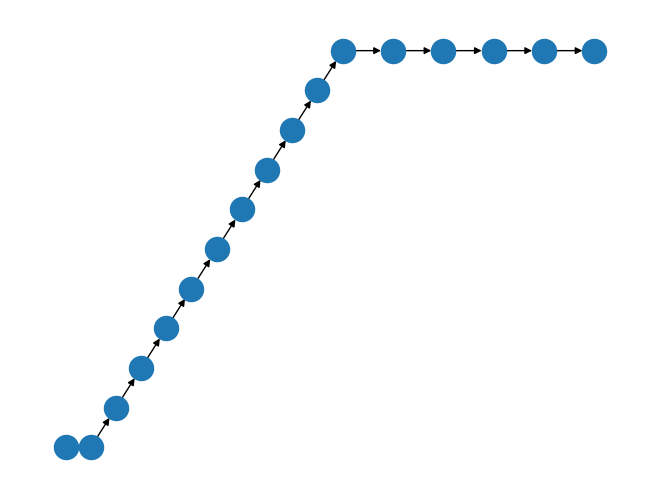

In [16]:
# Compiling our model
m.confirmation = True
m.simulation_check_compile()

In [17]:
# Get a summary of the model and its resources used
m.get_summary()


        Resources Used:
        - Total length of road used: 400 units
        - Total number of lanes: 3
        Key Nodes:
        - Inputs: [1]
        - Sinks: ['ralphs']
        - Sink destination amounts/Total traffic: {(1, 'ralphs'): 40}
        


## Simulation and Visualization<a name="simulation"></a>

So with our model instantiated, we turn to simulating traffic flow, which we do in **discrete time**. This update process is programmed within our `update_time` method in `traffix.py`. We make two main modeling contributions here: green lights and congestion.

For motivation, consider a traffic model with simultaneous road updates; i.e. all roads receive and relay cars at once. The process gets rather difficult to model and particularly clunky to visualize, so to accomodate this difficulty while still maintaining some realism is to take inspiration from a typical sight at an intersection; traffic lights. So, for each time step, our model updates each road segment one-by-one, sending cars into the intersection as if a green light was occurring at that time. 

Our second main modeling contribution here was our decision in modeling how congestion might occur in a road network. Our underlying idea is simple; the rate at which cars move through a road should be dependent on the "emptiness" or lack of traffic in the edge(s) ahead of it, as you move only as fast as the guy ahead of you. Thus, we calculate a `speed_factor` based on this measure, and multiply it by a constant, `idealSPLPG` (ideal number of cars to send, per lane, per green light), and the number of lanes to calculate the number of cars an edge will send into a subsequent one. Thus intuitively, if an edge ahead has a large capacity filled, then the edges before will send cars through at a slower rate. Eventually, if a road segment manages to reach full capacity, the ones before will not be able to push more cars through, eventually causing a backlog (see the "Bridge" example further below). Finally, for edges that lead to a termination point, the calculated number of cars to send will leave the network and be added to that sink's `terminations` count.

### Animation

We utilize Matplotlib's `FuncAnimation` along with our `update_time` function and NetworkX drawing capabilities to animate the traffic flow within a TraffiX model. There are many different labels to visualize, such as the number of cars on each road segment at a given time, the speed_factors, etc, but for elegance of presentation, we decided to highlight these three main features in the following ways:

- The `num_cars` on each road is normalized to a `Reds` colormap to color the edges based on how many cars are on it
- The `lanes` attribute for an edge contributes to the edge width
- The number of terminations at each node is labeled.

Below are some snippets from our `update` function `FuncAnimation` uses.
```python
def update(frame):
        ax.clear()  # Clear previous frame, update progress bar
# ...
        # Update traffic by one time step
        m.update_time()

        # Update edge_colors
        num_cars = nx.get_edge_attributes(m.G, 'num_cars')
        norm = plt.Normalize(0, 10)
        edge_colors = [cm.Reds(norm(num_cars[edge])) for edge in m.G.edges]
        
        # Update edge_widths 
        num_lanes = nx.get_edge_attributes(m.G, 'lanes')
        norm = plt.Normalize(0, 1)
        edge_widths = [norm(num_lanes[edge])**2 + 7 for edge in m.G.edges]

        # Redraw graph
        nx.draw(m.G, m.node_positions, ax=ax, with_labels=False, 
                node_color=node_colors, node_size=0, 
                edge_color=edge_colors, width=edge_widths)
# ...
```

So let us see it in action. We'll take from the in-package models in `playkit.py`, specifically the `template_bridge` model to showcase congestion and how changing the number of lanes on the bridge can improve traffic.

#### 1-lane bridge

```python
m = tpk.template_bridge(num_bridge_lanes = 1)
tv.simulate(m)
```

![onelane](onelane.png)

***For webpage storage restrictions, these animations were unfortunately not able to be displayed here. Please refer to the "TraffiX Demo" Python Notebook to see these animations.***

#### 3-lane bridge

```python
m = tpk.template_bridge(num_bridge_lanes = 3)
tv.simulate(m)
```

![threelane.png](threelane.png)

As you can see, TraffiX accurately models the performance improvement by adding more lanes to the bridge, resulting in a higher number of terminations in the 3-lane model over the 1-lane model. The 3-lane model also highlights how the roads before the bridge don't have as much backlog as before and the increased capacity of the 3-lane bridge.

## TraffiXEarth, real-world integration with OSMNX<a name="traffixearth"></a>

Building your own models is great an all, but can get tedious at times; after all, one has to formally declare the positions of every intersection, instantiate the roads, the lanes, the lengths, and more. Thus, the main motivation behind our **TraffiXEarth** feature (*traffixearth.py*) is to make this model construction process as easy as typing in a set of coordinates to get a road network model of some location on Earth.

TraffiXEarth accomplishes this by utilizing the OpenStreetMap NetworkX package, which returns a NetworkX graph of the road network of a certain location, equipped with data on the coordinates of the intersections, the lengths of the roads, the number of lanes, and much more. `traffixearth.py` takes this information and processes it first converting the nodes and edges into GeoPandas dataframes, and instantiating a TraffiX model using the provided data. Below is a snippet of the cleaning process the function `irl_to_traffix_model` performs, from normalizing WGS-84 coordinates to rounding road lengths, to filling in NaN lane values:

```python
    # Get positions based on node coordinates for more accurate visualization
    nodes, edges = ox.graph_to_gdfs(G)
    nodes = nodes.reset_index()
    edges = edges.reset_index()
    # Normalize coords
    nodes['xpos'] = (nodes['x'] - nodes['x'].min()) / (nodes['x'].max() - nodes['x'].min())
    nodes['ypos'] = (nodes['y'] - nodes['y'].min()) / (nodes['y'].max() - nodes['y'].min())
    
    # Round edge lengths to nearest multiple of 50, nonzero (for seg_len purposes in traffix.py)
    edges['length'] = round(edges['length'] / 50, 0) * 50
    edges.loc[edges['length'] == 0, 'length'] = 50
    
    # Fill in lane NaN and invalid values (e.g. lists) with 1
    edges['lanes'].fillna(1, inplace=True)
    edges['lanes'] = edges['lanes'].apply(lambda x: 1 if isinstance(x, list) else x)
    edges['lanes'] = edges['lanes'].astype(int)
```



Now the most critical shortcoming of TraffixEarth (at least, in version 1.0) is that TraffiX models currently only support directed acyclic graphs (DAGs), which apply only to a very small subset of real world road networks. For this reason, TraffiXEarth very crudely performs some edge deletion to achieve this result, by removing cycles and isolated points to achieve a weakly-connected (essentially can draw the graph without picking up your pencil), DAG. This is the purpose of the following assertions to ensure TraffixEarth has achieved this result:
```python
assert nx.is_weakly_connected(G), "Invalid Area. Resulting map is not weakly connected/not present."
assert nx.is_directed_acyclic_graph(G), "Invalid Area. Modifications did not produce a DAG. Please choose a different area."
```
While our initial motivation was just an easier way to construct TraffiX models, this feature is definitely something that we look to improve in future versions of TraffiX, potentially allowing for user selection of edges to delete or keep, or removing the acyclic restriction altogether. We return to this in the discussion in the next section. For now, let's see TraffiXEarth in action, with taking a subset of the road network in Downtown Chicago.


    Uncompiled model of IRL road network at (41.880511, -87.632761) with radius 500 returned.
    Please declare input nodes and initialize number of cars to sinks before compilation.
    The current summary of the graph (with sinks) and a sketch of the graph are below.
    

        Resources Used:
        - Total length of road used: 3800.0 units
        - Total number of lanes: 40
        Key Nodes:
        - Inputs: []
        - Sinks: [27440225, 2390751536, 262184214]
        - Sink destination amounts/Total traffic: {}
        

    For reference, the root nodes that can serve as potential inputs are:
    [262184217, 3447462591]
    Initialize inputs with:
    - .declare_inflow_node(source_node (its name), initial_cars_to_sinks (dictionary, sinks are keys, num_cars are values))
    


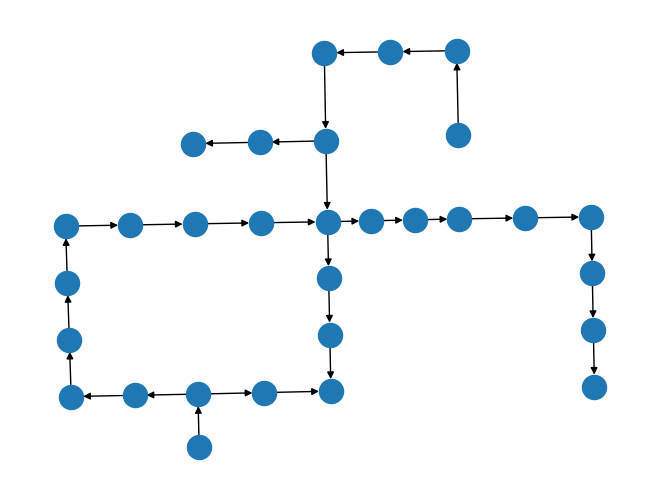

In [46]:
dtchi = te.irl_to_traffix_model(coordinates=(41.880511, -87.632761), radius=500)

```python
# 262184217, 3447462591 roots
# 27440225, 2390751536, 262184214 sinks
dtchi.declare_inflow_node(262184217, {27440225:40, 2390751536:40, 262184214:40})
dtchi.declare_inflow_node(3447462591, {27440225:40, 2390751536:40, 262184214:40})
dtchi.simulation_check_compile()
tv.simulate(dtchi)
```

![chicago.png](chicago.png)

## Discussion and Concluding Remarks<a name="discussion"></a>

This first version of TraffiX is crude and rather simple, but still showcases a lot of potential in modeling and simulating traffic congestion phenomena that, if tinkered with, could provide utility to urban planners in many cities. Besides that, anyone can install TraffiX and begin to play around with modeling on their own, creating their own road networks, initializing cars and traffic, and seeing the flow throughout with the outputted animation, making it an engaging and interactive user experience. 

There are many shortcomings to tackle in future iterations of this project. The main crux of these is our directed and acyclic graph assumptions. As of now, there actually aren't many parameters and modeling choices that rely on this assumption. The one parameter in particular that relies on this is the calculation of the intersection turn proportions, which use the fact that given a DAG, there are only a finite number of paths from any given source node to a sink point. However, this issue could also be alleviated by incorporating some additional real-world data into our model. *Traffic counts* are available for some cities, which track the number of cars going through and turning at intersections. In the future, we may look into drawing this data, potentially live from an API or database, and instantiating turn probabilities using these, which would likely eliminate the need for a DAG assumption.

This brings us to our last point, which are the potential ethical ramifications of this project. For one, utilizing traffic count data could raise some eyebrows, particularly on the order of how specific it can get. However, for large, densely populated urban centers, where traffic modeling is likely the most necessary, it's unlikely utilizing the traffic count data on millions of drivers could lead to potential privacy issues. Another concern is the computational power of these simulations. In this project, we've limited the simulations to relatively small models, no bigger than maybe fifty nodes. However, even running the simulation for 150 frames took a rather long time, and if TraffiX modeling is used on a large urban scale, the computational price would balloon greatly. In future iterations, we could look into more macroscopic models and utilize more graph theory to "reduce" the complexity of graphs by, for example, looking at strongly clustered components instead of individual nodes/intersections. Finally, we must emphasize that in TraffiX, we make many critical assumptions, from the green-light non-simultaneous updates, to the speed_factor calculation and the idea of only moving as fast as the person in front of you, and many more. While we've displayed some common traffic phenomena in real life, the results of the simulations across all road networks should be taken with a grain of salt and not as a panacea for potential traffic policy decisions.

Thanks for reading! We hope you enjoy playing around with **TraffiX**.

## Documentation and User Reference<a name="documentation"></a>

#### **Class**: `Map`

Represents a road network TraffiX model using NetworkX. Provides methods to construct a directed graph with roads and intersections, declare inflow nodes, check and compilation of model for simulation, and run time-step updates for traffic movement.

`__init__`
Initializes an empty directed graph and key parameters for TraffiX model.

Arguments:

- `capacity_per_length_per_lane` (float, default=0.5) – Defines road segment capacity per unit length per lane.
- `green_lights_per_time` (int, default=3) – Number of roads that get green lights per time step.
- `ideal_send_per_lane_per_green` (int, default=10) – Ideal number of cars sent per lane per green light cycle.
- `confirmation_messages` (bool, default=True) – Enables or disables confirmation print messages.

Returns: None

`add_inter(label, pos)`
Adds an intersection node to the graph with a given position.

Arguments:

- `label` (str or int) – The intersection's unique identifier.
- `pos` (tuple of float) – The (x, y) coordinates of the intersection.

Returns: None


`add_road(start, end, dt, speed_limit, length, lanes, num_cars=0)`
Adds a segmented road between two intersections.

Arguments:

- `start` (str or int) – The starting intersection.
- `end` (str or int) – The ending intersection.
- `dt` – to be implemented
- `speed_limit` – to be implemented
- `length` (float) – Length of the road segment.
- `lanes` (int) – Number of lanes on the road.
- `num_cars` (int, default=0) – Initial number of cars on the road.

Returns: None


`get_summary()`
Prints a summary of the road network, including resource metrics such as total road length, number of lanes, input nodes, sink nodes, and traffic inputs-sinks distributions.

Arguments: None

Returns: None

`declare_inflow_node(source_node, initial_cars_to_sinks)`
Declares an inflow node and adds cars entering the system via dictionary.

Arguments:

- source_node (str or int) – The input node where cars enter the system.
- initial_cars_to_sinks (dict) – Mapping of sink nodes to the number of cars sent toward them.

Returns: None

`add_road_segment(start, end, dt, speed_limit, length, lanes, num_cars=0)`
Adds a road segment between two nodes without intermediate intersections.

Arguments:

- Same as add_road().

Returns: None

`simulation_check_compile()`
Ensures the road network is acyclic before simulation, initializes sinks and terminations attributes, calculates and assigns intersection turn proportions, and displays a network visualization and summary (if self.confirmation == True).

Arguments: None

Returns: None

`update_time()`
Simulates a single time step of traffic movement.

Arguments: None

Returns: None

#### **Function**: `simulate`
The `simulate` function animates a TraffiX model traffic simulation over a specified number of frames, visualizing the traffic flow through a road network.

`simulate(m, frames=150)`

Arguments:

- `m` (Map object): An instance of a TraffiX model, containing a networkx graph (m.G), node positions (m.node_positions), and methods for updating the simulation (m.update_time()).
- `frames` (int, default=150): Number of time steps to run the simulation.

Returns:

- HTML FuncAnimation object containing a matplotlib animation of the traffic simulation.

#### **Function**: `irl_to_traffix_model`
The `irl_to_traffix_model` function converts real-world NetworkX road networks from OpenStreetMap into a directed acyclic graph (DAG) compatible with TraffiX modeling and simulation.

`irl_to_traffix_model(coordinates, radius)`

Arguments:

- coordinates (tuple): Latitude and longitude of the location to map.
- radius (float): The radius (in meters) around the given coordinates to extract road data.

Returns:

- A TraffiX model `Map` object of the road network in a format that can be simulated.

#### **Function**: `template_2input_1sink`

Returns: 

- A simple road network model (Map object) with two input sources and one sink.

#### **Function**: `template_bridge(num_bridge_lanes=1, speed_limit=50)`

Arguments:

- num_bridge_lanes (int): Number of lanes on the bridge (must be ≥ 1).
- speed_limit: to be implemented

Returns: 

- A bridge traffic model (Map object) with variable lane capacity.